ESERCIZIO

Carica un'immagine e convertila in scala di gridi.
Esegui una binarizzazione con una sola soglia di 150
Una volta ottenuta l'immagine binaria:
    - Convertila in float32
    - Normalizza nel range (0,1)
    - Calcola la percentuale di pixel 'attivi' (bianchi) rispetto al totale utilzzando solo funzione NumPy

spiega perchè, in un contesto di Deep Learnig, questa misura potrebbe essere utile (es per il calcolo della densità di oggetti)

Scaricamento immagine casuale da internet...
Shape dell'immagine (H, W, C): (400, 600, 3)
Tipo di dato originale: uint8
Percentuale pixel attivi (bianchi): 59.45%


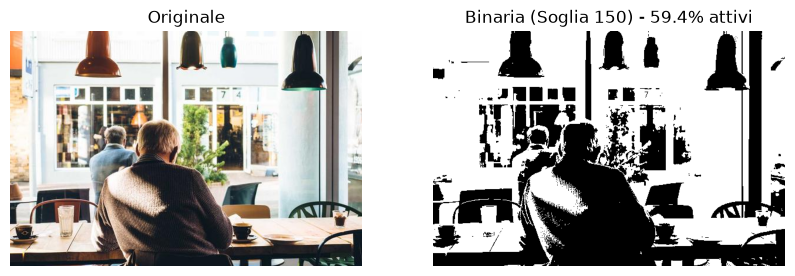

In [2]:
import os
import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt
import keras
from io import BytesIO

# --- CONFIGURAZIONE BACKEND ---
os.environ["KERAS_BACKEND"] = "torch"

def explore_image_arrays():
    # 1. DOWNLOAD IMMAGINE CASUALE
    print("Scaricamento immagine casuale...")
    url = "https://picsum.photos/600/400"
    try:
        response = requests.get(url, timeout=10)
        file_bytes = np.frombuffer(response.content, np.uint8)
        img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    except Exception:
        img_bgr = np.random.randint(0, 256, (400, 600, 3), dtype=np.uint8)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    
    # 2. BINARIZZAZIONE (Soglia 150)
    # Cambiata la soglia da 127 a 150 come richiesto
    _, img_binary = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY)

    # 3. CONVERSIONE, NORMALIZZAZIONE E CALCOLO PERCENTUALE
    # Convertiamo in float32 e scaliamo in [0, 1]
    img_bin_float = img_binary.astype(np.float32) / 255.0
    
    # Calcolo percentuale pixel attivi (bianchi) usando NumPy
    # Poiché l'immagine è 0.0 o 1.0, la media coincide con la frazione di 1.0
    percentuale_attivi = np.mean(img_bin_float) * 100
    print(f"Percentuale pixel attivi (bianchi): {percentuale_attivi:.2f}%")

    # 4. VISUALIZZAZIONE
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Originale")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Binaria (Soglia 150) - {percentuale_attivi:.1f}% attivi")
    plt.imshow(img_bin_float, cmap='gray')
    plt.axis('off')
    plt.show()

    # 5. SALVATAGGIO
    keras.utils.save_img("binary_result.png", np.expand_dims(img_binary, axis=-1))

if __name__ == "__main__":
    explore_image_arrays()